In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

BASE_DIR = Path.cwd().parent
file_path = BASE_DIR / 'tabs_and_figs'
print(file_path)

c:\Users\Wang0\Documents\UNSW\Honours Thesis\code\tabs_and_figs


# Background

## Quant Question

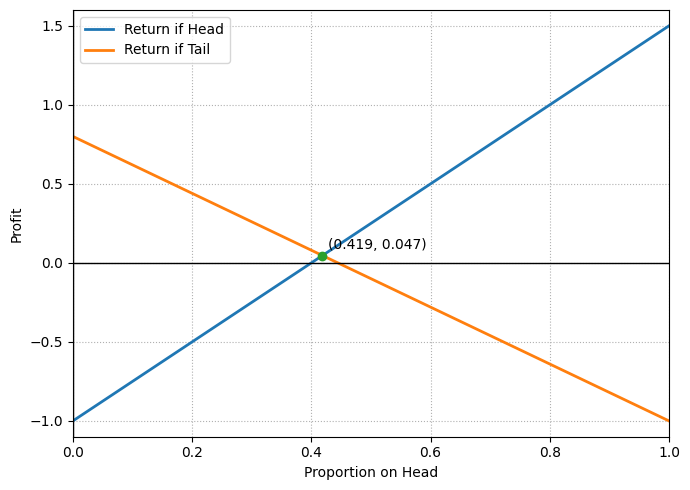

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Functions
def y1(x):  # red line in your Desmos: y = 2.5x - 1
    return 2.5*x - 1

def y2(x):  # blue line: y = 1.8(1 - x) - 1 = -1.8x + 0.8
    return -1.8*x + 0.8

# Domain and values
x = np.linspace(0, 1, 400)
Y1, Y2 = y1(x), y2(x)

# Intersection: solve 2.5x - 1 = -1.8x + 0.8
xi = 1.8 / (2.5 + 1.8)         # = 18/43 ≈ 0.4186046512
yi = y1(xi)                    # ≈ 0.0465116279

# Plot
plt.figure(figsize=(7, 5))
plt.plot(x, Y1, label='Return if Head', linewidth=2)
plt.plot(x, Y2, label='Return if Tail', linewidth=2)
plt.plot(xi, yi, 'o', ms=6)  # intersection dot
plt.text(xi+0.01, yi+0.04, f'({xi:.3f}, {yi:.3f})')

# Axes through origin
plt.axhline(0, linewidth=1, color='black')
plt.axvline(0, linewidth=1, color='black')

# Limits, labels, grid, legend
plt.xlim(0, 1)
plt.ylim(-1.1, 1.6)
plt.xlabel('Proportion on Head')
plt.ylabel('Profit')
plt.grid(True, linestyle=':')
plt.legend()
plt.tight_layout()

# Save (vector and raster)
plt.savefig(file_path / 'ch1_game_profit.png', dpi=600)
plt.show()


## Call and Put Payoff and PnL

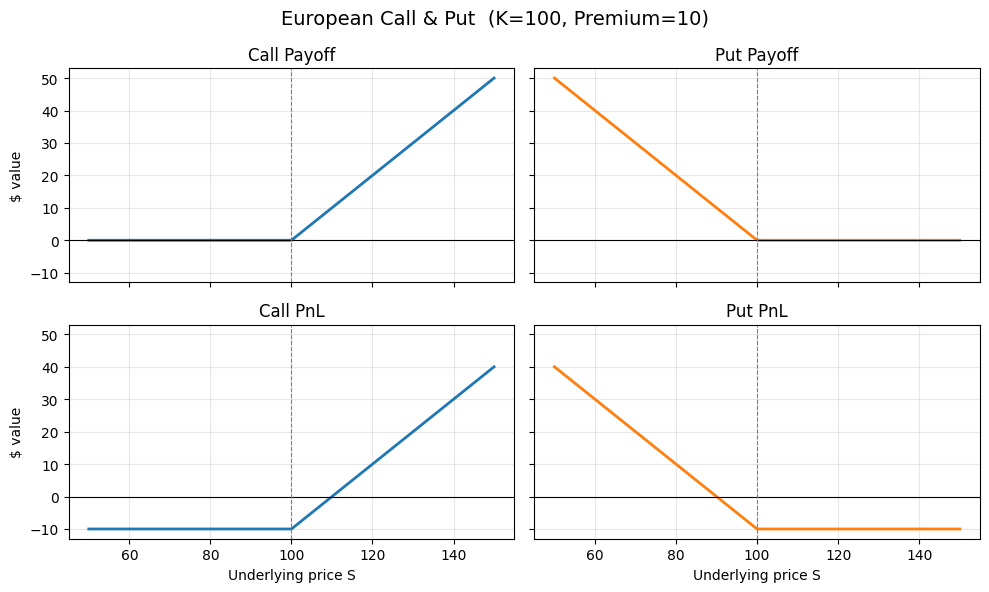

In [3]:
import numpy as np
import matplotlib.pyplot as plt

K = 100
P = 10
S = np.linspace(50, 150, 500)

# Payoffs at expiry
call_payoff = np.maximum(S - K, 0)
put_payoff  = np.maximum(K - S, 0)

# PnL = payoff - premium
call_pnl = call_payoff - P
put_pnl  = put_payoff  - P

fig, axes = plt.subplots(2, 2, figsize=(10, 6), sharex=True, sharey=True)
fig.suptitle(f"European Call & Put  (K={K}, Premium={P})", fontsize=14)

plots = [
    (axes[0, 0], call_payoff, "Call Payoff",  "tab:blue"),
    (axes[0, 1], put_payoff,  "Put Payoff",   "tab:orange"),
    (axes[1, 0], call_pnl,    "Call PnL",     "tab:blue"),
    (axes[1, 1], put_pnl,     "Put PnL",      "tab:orange"),
]

for ax, y, title, color in plots:
    ax.plot(S, y, color=color, linewidth=2)
    ax.axhline(0, color="black", linewidth=0.8)
    ax.axvline(K, color="gray",  linewidth=0.8, linestyle="--")
    ax.set_title(title)
    ax.grid(alpha=0.3)

for ax in axes[1]:
    ax.set_xlabel("Underlying price S")
for ax in axes[:, 0]:
    ax.set_ylabel("$ value")

plt.tight_layout()

# save figure to path (BEFORE show)
plt.savefig(file_path / 'ch2_option_payoff_pnl.png', dpi=600)
plt.show()


## Straddle

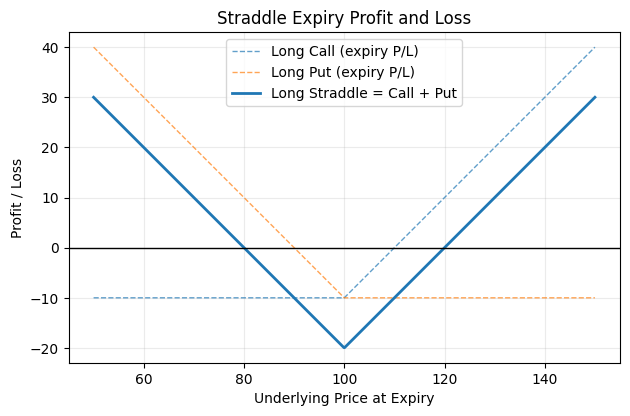

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from plot_utils import plot_straddle_payoff

plot_straddle_payoff(100, 10, 10, path = file_path / 'ch2_straddle_pnl.png', short = False)

## Butterfly

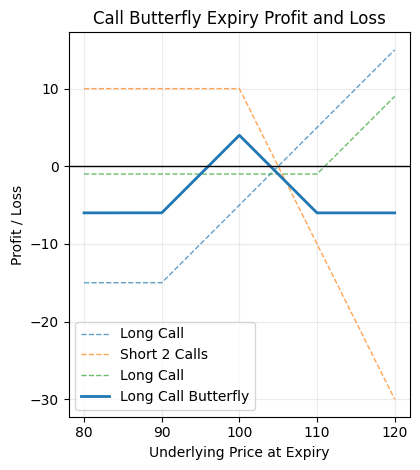

: 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from plot_utils import plot_call_butterfly_payoff

plot_call_butterfly_payoff(90, 100, 110, 15, 5, 1,
                           xlim = (80, 120),
                           path = file_path / 'ch2_butterfly_pnl.png',
                           short = False)

# VRP

## RV Estimate Intuition

Realised variance RV(S1): 0.00025
Realised variance RV(S2): 0.00617
Realised volatility RV^(1/2)(S1): 0.01572
Realised volatility RV^(1/2)(S2): 0.07853


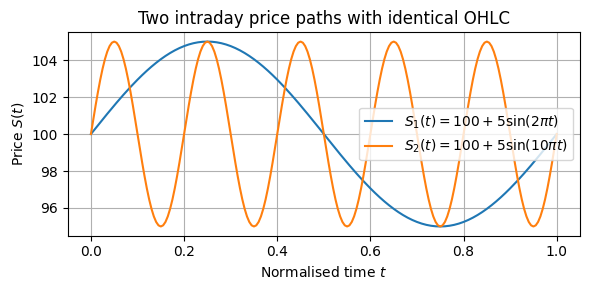

In [26]:
import numpy as np
import matplotlib.pyplot as plt

# 200 evenly spaced observation points on [0, 1]
t = np.linspace(0, 1, 201)

# Price paths
S1 = 100 + 5*np.sin(2*np.pi*t)
S2 = 100 + 5*np.sin(10*np.pi*t)

# Realised variance from log returns: sum (log(S_{j+1}/S_j))^2
rv1 = np.sum(np.diff(np.log(S1))**2)
rv2 = np.sum(np.diff(np.log(S2))**2)

print(f"Realised variance RV(S1): {rv1:.5f}")
print(f"Realised variance RV(S2): {rv2:.5f}")
print(f"Realised volatility RV^(1/2)(S1): {np.sqrt(rv1):.5f}")
print(f"Realised volatility RV^(1/2)(S2): {np.sqrt(rv2):.5f}")

# Plot
plt.figure(figsize=(6, 3))
plt.plot(t, S1, label=r"$S_1(t)=100+5\sin(2\pi t)$")
plt.plot(t, S2, label=r"$S_2(t)=100+5\sin(10\pi t)$")
plt.xlabel("Normalised time $t$")
plt.ylabel("Price $S(t)$")
plt.title("Two intraday price paths with identical OHLC")
plt.grid(True)
plt.legend()
plt.tight_layout()

# save figure to path (BEFORE show)
plt.savefig(file_path / 'vrp_rv_example.png', dpi=600)
plt.show()


## Show ticker universe histogram

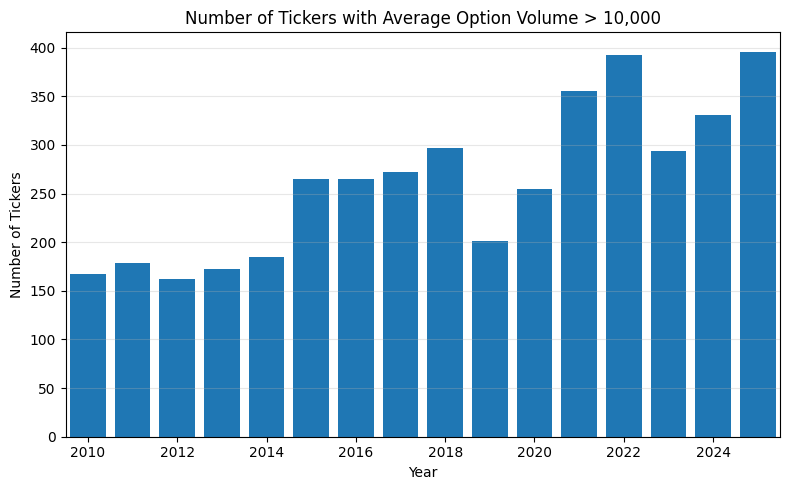

In [27]:
def load_tickers(
    path: str | Path,
    start_year: int,
    end_year: int,
    volume_threshold: int = 10_000
) -> dict[int, list[str]]:

    tickers_by_year: dict[int, list[str]] = {}
    for year in range(start_year, end_year + 1):
        df = pd.read_excel(path, sheet_name=f"{year}")
        df = df[df["avg_option_volume"] > volume_threshold] # filter avg_option_volume > volume_threshold
        tickers = df["ticker"].tolist()
        tickers_by_year[year] = tickers

    return tickers_by_year

tickers_dict = load_tickers(BASE_DIR / "data" / "ticker_universe.xlsx", start_year=2010, end_year=2025, volume_threshold=10_000)

# plot histogram of number of tickers per year
plt.figure(figsize=(8, 5))
plt.bar(tickers_dict.keys(), [len(tickers) for tickers in tickers_dict.values()])
plt.xlabel("Year")
plt.ylabel("Number of Tickers")
plt.title("Number of Tickers with Average Option Volume > 10,000")
plt.xlim(2010-0.5, 2025+0.5)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(file_path / 'ticker_universe_histogram.png', dpi=600)
plt.show()